<a href="https://colab.research.google.com/github/Methura/Methura-PM/blob/main/face%20recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Found your images in: dataset_root/personalities
Training on new personalities: ['Bose', 'Gandhi', 'Kalam', 'Nehru']
Starting Training for 50 Epochs...
Epoch 10/50 Loss: 0.5875
Epoch 20/50 Loss: 0.6534
Epoch 30/50 Loss: 0.3491
Epoch 40/50 Loss: 0.3617
Epoch 50/50 Loss: 0.1172

Displaying exactly one of each: ['Bose', 'Gandhi', 'Kalam', 'Nehru']


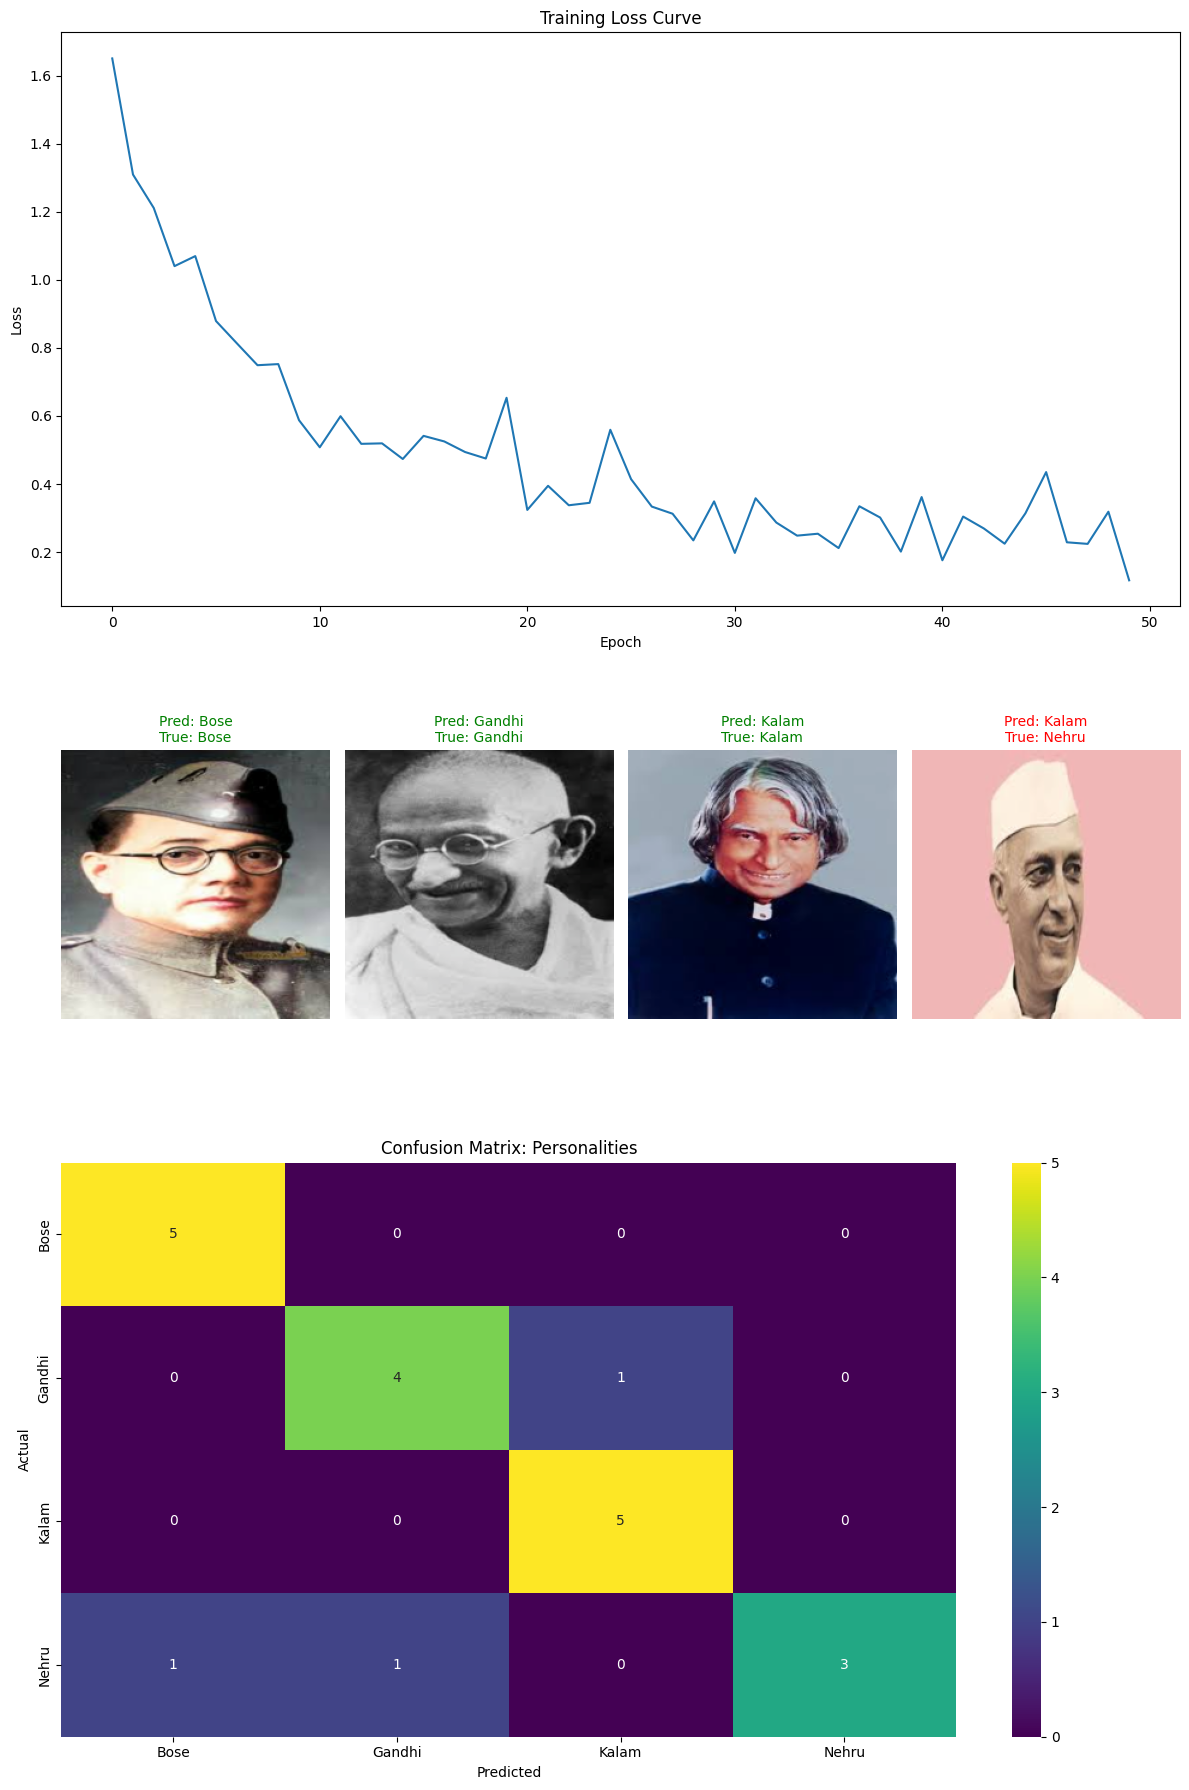

In [6]:
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
zip_path = "Indians.zip"
extract_path = "dataset_root"
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extracted dataset!")
data_dir = extract_path
for root, dirs, files in os.walk(extract_path):
    if 'train' in dirs and 'test' in dirs:
        data_dir = root
        break
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_data = datasets.ImageFolder(train_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=4)
class_names = train_data.classes
print(f"Found your images in: {data_dir}")
print(f"Training on new personalities: {class_names}")
model =(models.resnet18(weights=ResNet18_Weights.DEFAULT))
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
loss_history = []
print("Starting Training for 50 Epochs...")
for epoch in range(50): # Run 50 epochs for a nice smooth curve
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 Loss: {epoch_loss:.4f}")
plt.figure(figsize=(12, 18))
plt.subplot(3, 1, 1)
plt.plot(loss_history, color='tab:blue')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
model.eval()

def get_one_of_each(dataset):
    indices = []
    found_classes = set()

    for i in range(len(dataset)):
        label = dataset.samples[i][1]
        if label not in found_classes:
            indices.append(i)
            found_classes.add(label)
        if len(indices) == len(dataset.classes):
            break
    return indices
specific_indices = get_one_of_each(test_data)
images = torch.stack([test_data[i][0] for i in specific_indices])
labels = torch.tensor([test_data[i][1] for i in specific_indices])
with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')

print(f"\nDisplaying exactly one of each: {class_names}")
for i in range(len(specific_indices)):
    plt.subplot(3, 4, 5 + i)
    color = "green" if preds[i] == labels[i] else "red"
    title = f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}"
    imshow(images[i], title=title)
    plt.gca().title.set_color(color)
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        outputs = model(imgs.to(device))
        _, preds_cm = torch.max(outputs, 1)
        all_preds.extend(preds_cm.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.subplot(3, 1, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: Personalities")
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()
